<a href="https://colab.research.google.com/github/Val095/InteligenciaArtificial_II/blob/main/prediccion_precios_vivienda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Predicción del costo de viviendas mediante Machine Learning

**Actividad académica — Ingeniería de Software**

En este proyecto comparo dos modelos de regresión para predecir el **valor mediano de las viviendas** en bloques de California (EE. UU.):

1. **Regresión Lineal** — un modelo que asume que el precio puede explicarse como una suma ponderada de las características.
2. **Árbol de Decisión para regresión** — un modelo que divide el espacio de características en regiones y predice un valor promedio para cada región.

**Dataset utilizado:** California Housing, disponible directamente en `sklearn` (se carga sin necesidad de subir archivos a Colab).

**Unidad de la variable objetivo:** `MedHouseVal` está expresada en **cientos de miles de dólares estadounidenses**. Es decir, un valor de `2.0` equivale a una vivienda de aproximadamente **USD $200,000**.

> 💡 *Nota: la estructura de este notebook sigue la lógica del ejercicio de introducción de Kaggle de Alexis Cook, pero el código, los comentarios y el análisis están adaptados a este dataset y escritos con mi propio razonamiento.*

## 1. Introducción

El objetivo es responder una pregunta concreta: **¿puedo estimar cuánto vale una vivienda conociendo características como los ingresos medios del vecindario, su antigüedad, el número promedio de habitaciones y su ubicación geográfica?**

Para responderla sigo este camino:

**comprensión del dataset → limpieza → selección de variables → entrenamiento → evaluación → comparación → análisis → conclusiones.**

Cada decisión (qué registros quito, cómo trato los valores atípicos, qué profundidad le doy al árbol) está justificada en las celdas de abajo.

## 2. Importación de librerías

Agrupo aquí todo lo que necesito: pandas y numpy para manejar los datos, matplotlib y seaborn para las gráficas, y las clases de `sklearn` para cargar el dataset, dividirlo, entrenar los dos modelos y calcular las métricas.

In [ ]:
import pandas as pd  # Pandas me sirve para cargar el dataset en un DataFrame y manipularlo como una tabla.
import numpy as np  # Numpy me ayuda con cálculos numéricos, especialmente operaciones estadísticas sobre los datos.
import matplotlib.pyplot as plt  # Matplotlib es la librería base para dibujar las gráficas que me permitirán entender los datos y los resultados.
import seaborn as sns  # Seaborn me facilita hacer gráficas estadísticas más bonitas y con menos código.

from sklearn.datasets import fetch_california_housing  # Traigo el dataset de vivienda de California desde sklearn, así no dependo de subir archivos a Colab.
from sklearn.model_selection import train_test_split  # Esta función me permite dividir mis datos en entrenamiento y prueba de forma controlada.
from sklearn.linear_model import LinearRegression  # Importo el modelo de regresión lineal, el primer modelo que voy a comparar.
from sklearn.tree import DecisionTreeRegressor  # Importo el árbol de decisión para regresión, que será mi segundo modelo.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Estas son las métricas con las que mediré qué tan bien predicen los modelos.

## 3. Carga del dataset

Cargo el dataset como un DataFrame de pandas para explorarlo con las herramientas que ya conozco, y muestro las primeras filas para verificar que la carga funcionó.

In [ ]:
datos = fetch_california_housing(as_frame=True)  # Cargo el dataset completo como un objeto que incluye la tabla y su descripción.
df = datos.frame  # Extraigo la tabla completa (características + precio) en un solo DataFrame para trabajar con ella.
df.head()  # Muestro las primeras 5 filas para tener una primera impresión de cómo están organizados los datos.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Exploración de los datos

Antes de tocar cualquier modelo necesito **entender qué tengo en las manos**. Una predicción hecha sobre datos que no entiendo es una predicción en la que no confío.

### 4.1 Dimensiones y nombres de columnas

In [ ]:
print("Filas y columnas:", df.shape)  # Quiero saber cuántos datos tengo, porque eso me da una idea del tamaño del problema y de si tengo suficientes ejemplos para entrenar.
print("Nombres de las columnas:", list(df.columns))  # Reviso los nombres exactos para entender qué información contiene cada columna antes de usarla.

Filas y columnas: (20640, 9)
Nombres de las columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


**¿Qué significa cada columna?**

| Columna | Significado |
|---|---|
| `MedInc` | Ingreso mediano del hogar en el bloque (en decenas de miles de USD) |
| `HouseAge` | Edad mediana de las viviendas del bloque (años) |
| `AveRooms` | Promedio de habitaciones por hogar |
| `AveBedrms` | Promedio de dormitorios por hogar |
| `Population` | Población del bloque |
| `AveOccup` | Promedio de ocupantes por hogar |
| `Latitude` / `Longitude` | Ubicación geográfica del bloque |
| `MedHouseVal` | **Variable objetivo:** valor mediano de la vivienda (cientos de miles de USD) |

### 4.2 Tipos de datos, valores nulos y duplicados

In [ ]:
df.info()  # Veo el tipo de dato de cada columna y cuántos valores no nulos tiene, para detectar de entrada si hay columnas incompletas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.isnull().sum()  # Cuento los nulos por columna; si hubiera nulos tendría que decidir una estrategia (imputar o eliminar) antes de entrenar.

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
df.duplicated().sum()  # Verifico si hay filas repetidas, porque los duplicados podrían sesgar el entrenamiento al sobre-representar ciertos casos.

np.int64(0)

**Observación:** el dataset está limpio en ese sentido: **0 valores nulos y 0 filas duplicadas**. Esto es una ventaja, porque no necesito aplicar imputación ni eliminar duplicados. Aun así, eso no significa que no haya problemas: los **valores atípicos** los reviso en el siguiente paso con las estadísticas descriptivas.

### 4.3 Estadísticas descriptivas

In [ ]:
df.describe()  # Obtengo media, desviación, mínimos, máximos y percentiles para detectar valores raros o atípicos antes de entrenar.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**Lo que observo al leer la tabla:**

* `AveOccup` tiene un máximo de **1243 ocupantes por hogar**, lo cual es imposible en la vida real: son datos erróneos o casos degenerados.
* `AveRooms` y `AveBedrms` también tienen máximos muy alejados del percentil 75, lo que sugiere valores extremos.
* `MedHouseVal` tiene un máximo de **5.00001**, un valor *redondeado y truncado*: el censo original limitó los precios altos. Esto es un **censoring** del dato, algo importante de tener en cuenta al interpretar los resultados.
* `MedInc` (ingreso mediano) concentra el rango más razonable de valores y, por intuición, debería estar fuertemente relacionado con el precio.

### 4.4 Variable objetivo y relación con el precio

In [ ]:
df['MedHouseVal'].describe()  # Analizo la variable objetivo (el precio) para entender su distribución, su rango y si está sesgada.

,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


In [ ]:
correlaciones = df.corr(numeric_only=True)['MedHouseVal'].sort_values(ascending=False)  # Calculo la correlación de cada variable con el precio para tener una primera idea de cuáles podrían ser más útiles para predecir.
correlaciones  # Muestro el ranking: mientras más cerca de 1 o -1, más fuerte es la relación lineal con el precio.

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


**Lectura de las correlaciones:**

* `MedInc` (ingreso mediano) tiene una correlación de **0.69** con el precio: es, con diferencia, la variable más relacionada. Tiene sentido: los hogares con más ingresos tienden a vivir en zonas donde las casas valen más.
* `AveRooms` (0.15) y `HouseAge` (0.11) tienen correlaciones débiles pero positivas.
* `Latitude` y `Longitude` tienen correlaciones negativas moderadas (~ -0.14 / -0.05): la ubicación sí importa, pero su efecto es **geográfico y no lineal** (las costas son caras, el interior barato), algo que un modelo lineal solo puede capturar de forma aproximada.
* `Population` y `AveOccup` prácticamente no se correlacionan con el precio.

Esto ya me da una pista de lo que vendrá: **si la relación fuera puramente lineal, la regresión lineal sería suficiente; pero la ubicación geográfica sugiere que hay patrones no lineales que un árbol podría capturar mejor.**

## 5. Limpieza y preparación de los datos

### 5.1 Detección razonada de valores atípicos

De la estadística descriptiva sospeché que `AveOccup` tiene valores imposibles. Lo confirmo contándolos, y de paso cuento los registros con el precio truncado en 5.0 para documentarlo (esos **no los elimino**, porque son precios reales reportados, solo limitados por el censo; eliminarlos quitaría justo las viviendas más caras y sesgaría el modelo).

In [ ]:
print("Registros con AveOccup > 20:", (df['AveOccup'] > 20).sum())  # Cuento cuántos registros tienen una ocupación promedio absurda; más de 20 personas por casa no es realista.
print("Registros con precio tope (>= 5.0):", (df['MedHouseVal'] >= 5.0).sum())  # Cuento los valores truncados del censo, solo para documentar el fenómeno, no para eliminarlos.

Registros con AveOccup > 20: 10
Registros con precio tope (>= 5.0): 992


### 5.2 Aplicación de la limpieza

In [ ]:
df_limpio = df[df['AveOccup'] < 20].copy()  # Elimino los registros con ocupación promedio irreal (más de 20 personas por casa), porque son errores que confundirían a los modelos.
print("Registros eliminados:", df.shape[0] - df_limpio.shape[0])  # Confirmo cuántos datos perdí; solo fueron 10 de 20,640, así que la limpieza es mínima y razonable.
df_limpio.shape  # Verifico las nuevas dimensiones del dataset limpio.

Registros eliminados: 10


(20630, 9)

### 5.3 Sobre el preprocesamiento de variables

* **Variables categóricas:** este dataset es 100 % numérico, por lo que **no es necesario aplicar One-Hot Encoding**. Si mi dataset tuviera columnas como `zona` o `tipo de vivienda`, sí tendría que convertirlas.
* **Escalado:** la regresión lineal de `sklearn` no exige escalado obligatoriamente, y el árbol de decisión es invariante a la escala (solo compara umbrales). Por eso, y para mantener el proyecto comprensible, **no aplico normalización** en esta versión.
* **Columnas eliminadas:** ninguna por completo. Las 8 características numéricas aportan algo, aunque sea poco (`Population` la conservo porque la pérdida de información al quitarla es menor que el riesgo de descartar algo útil sin analizarlo más a fondo).

## 6. Selección de variables

Separo claramente **qué uso para predecir** (X) y **qué quiero predecir** (y). La única columna que no puede estar en X es el propio precio, porque sería "hacer trampa": el modelo no tendría que predecir nada, solo copiar.

In [ ]:
X = df_limpio.drop(columns=['MedHouseVal'])  # Defino las variables predictoras: todas las columnas excepto el precio, que es lo que quiero estimar.
y = df_limpio['MedHouseVal']  # Defino la variable objetivo: el valor mediano de la vivienda, en cientos de miles de dólares.
print("X:", X.shape, "| y:", y.shape)  # Confirmo que X e y tienen el mismo número de filas; si no, algo salió mal en la separación.

X: (20630, 8) | y: (20630,)


## 7. División de los datos

Divido en **80 % entrenamiento / 20 % prueba** con `random_state=42` para que:

1. Los modelos aprendan con la mayoría de los datos.
2. La evaluación se haga con datos que **ningún modelo vio**, midiendo así la capacidad real de generalizar.
3. Los resultados sean **reproducibles**: cualquiera que ejecute este notebook obtendrá exactamente la misma división y los mismos números.

**Los dos modelos usarán exactamente los mismos conjuntos**, lo que hace justa la comparación.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Separo 80% para entrenar y 20% para probar, con semilla fija para poder reproducir los resultados.
print("Entrenamiento:", X_train.shape)  # Verifico el tamaño del conjunto de entrenamiento (debe ser cerca del 80%).
print("Prueba:", X_test.shape)  # Verifico el tamaño del conjunto de prueba (debe ser cerca del 20%).

Entrenamiento: (16504, 8)
Prueba: (4126, 8)


## 8. Modelo de Regresión Lineal

**¿Qué es la regresión lineal?** Es un modelo que aprende una ecuación del tipo:

> precio = w₁·MedInc + w₂·HouseAge + ... + w₈·Longitude + b

* **Qué intenta aprender:** los pesos (w) y el intercepto (b) que hacen que la predicción se aleje lo menos posible de los precios reales, minimizando el error cuadrático.
* **Variables independientes (X):** las 8 características de cada bloque (ingresos, antigüedad, habitaciones, ubicación...).
* **Variable dependiente (y):** el precio de la vivienda.

**¿Por qué es apropiada aquí?** `MedInc` tiene una correlación fuerte y positiva con el precio, así que una parte importante de la relación sí parece lineal. Es un buen modelo base: simple, rápido e interpretable.

**Sus limitaciones:** si el precio depende de la ubicación de forma geográfica (la costa es cara, el interior barato, sin una frontera "suave"), o si hay efectos combinados entre variables, una sola línea recta no puede doblarse para seguir ese patrón. En esos casos el modelo cometerá errores sistemáticos que un modelo no lineal podría evitar.

In [ ]:
modelo_lineal = LinearRegression()  # Creo el modelo de regresión lineal, que buscará la mejor combinación lineal de las características para estimar el precio.
modelo_lineal.fit(X_train, y_train)  # Entreno solo con los datos de entrenamiento; los de prueba quedan "ocultos" para evaluar después de forma honesta.
predicciones_lineal = modelo_lineal.predict(X_test)  # Uso el modelo entrenado para predecir los precios de las casas que nunca vio.
predicciones_lineal[:5]  # Miro las primeras 5 predicciones para verificar que los valores tienen sentido (están en la escala del precio, cientos de miles de USD).

array([0.75868565, 2.29258448, 2.75766961, 2.21183153, 0.82840221])

Un detalle interesante: puedo inspeccionar los **coeficientes** que el modelo aprendió, algo que solo los modelos lineales permiten tan directamente. Me dice "cuánto cambia el precio estimado cuando una característica sube en una unidad, manteniendo las demás constantes":

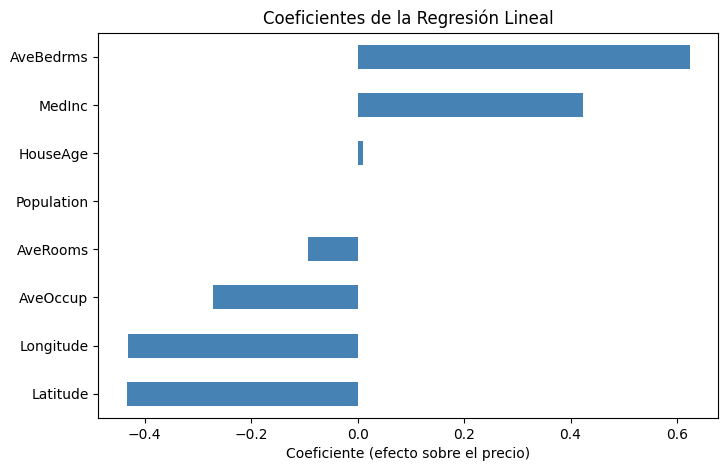

In [ ]:
importancias_lineales = pd.Series(modelo_lineal.coef_, index=X.columns).sort_values()  # Organizo los coeficientes por tamaño para ver qué características empujan el precio hacia arriba o hacia abajo.
importancias_lineales.plot(kind='barh', figsize=(8, 5), color='steelblue')  # Grafico los coeficientes en barras horizontales para compararlos visualmente.
plt.xlabel('Coeficiente (efecto sobre el precio)')  # Etiqueto el eje X indicando qué representa cada barra.
plt.title('Coeficientes de la Regresión Lineal')  # Título que describe que estamos viendo el peso que le dio el modelo a cada característica.
plt.show()  # Muestro la gráfica.

## 9. Modelo de Árbol de Decisión

**¿Qué es un árbol de decisión?** Un modelo que hace preguntas del tipo *"¿MedInc ≤ 3.5?"* y va dividiendo los datos en grupos cada vez más parecidos entre sí. Para predecir, toma una casa, la baja por las ramas según sus características, y **devuelve el precio promedio de las casas de entrenamiento que cayeron en la misma hoja**.

* **Cómo decide:** en cada nodo elige la característica y el punto de corte que mejor separan los datos (minimizando el error dentro de cada grupo).
* **Por qué sirve para precios:** puede capturar relaciones **no lineales** y de "umbrales": por ejemplo, que el precio sube rápido hasta cierto nivel de ingresos y luego se estabiliza.
* **Profundidad:** cuántas preguntas consecutivas hace como máximo. Más profundidad = divisiones más finas.
* **El riesgo: el overfitting.** Un árbol muy profundo termina creando una hoja para cada casa de entrenamiento: memoriza los datos en lugar de aprender el patrón general, y falla con datos nuevos. Por eso limito la profundidad con `max_depth=10` y fijo la semilla con `random_state=42`.

In [ ]:
modelo_arbol = DecisionTreeRegressor(max_depth=10, random_state=42)  # Creo el árbol limitando su profundidad a 10 niveles para que aprenda patrones generales y no memorice los datos de entrenamiento.
modelo_arbol.fit(X_train, y_train)  # Entreno el árbol con los MISMOS datos de entrenamiento, para que la comparación con la regresión lineal sea justa.
predicciones_arbol = modelo_arbol.predict(X_test)  # Predigo los precios del conjunto de prueba con el árbol para compararlo con el modelo lineal.

## 10. Evaluación de los modelos

Defino una función que calcula las cuatro métricas de una vez, así evito repetir código y me aseguro de que ambos modelos se miden con exactamente la misma regla. Las unidades están en **cientos de miles de dólares**.

* **MAE (Error Absoluto Medio):** promedio de cuánto se equivoca el modelo en las unidades del precio. Es la métrica más fácil de traducir a dinero.
* **MSE (Error Cuadrático Medio):** promedio del error al cuadrado. Penaliza fuertemente los errores grandes, pero queda en unidades "raras" (precio²).
* **RMSE (Raíz del MSE):** vuelve el MSE a las unidades del precio, dando más peso a los errores grandes que el MAE. Útil si me preocupan especialmente las predicciones muy malas.
* **R² (Coeficiente de determinación):** qué proporción de la variabilidad del precio logra explicar el modelo. Un R² de 0.63 significa que explica el 63 % de la variación; mientras más cerca de 1, mejor.

In [ ]:
def calcular_metricas(y_real, y_predicho, nombre_modelo):  # Creo una función que calcule todas las métricas de una vez, para no repetir código con cada modelo.
    mae = mean_absolute_error(y_real, y_predicho)  # MAE: promedio del error absoluto, me dice en promedio cuánto se equivoca el modelo en unidades del precio.
    mse = mean_squared_error(y_real, y_predicho)  # MSE: promedio del error al cuadrado, penaliza mucho las predicciones que fallan por mucho.
    rmse = np.sqrt(mse)  # RMSE: raíz del MSE, me devuelve el error a las unidades originales del precio para interpretarlo mejor.
    r2 = r2_score(y_real, y_predicho)  # R²: proporción de la variación del precio que el modelo logra explicar (mientras más cerca de 1, mejor).
    return {'Modelo': nombre_modelo, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}  # Devuelvo los resultados organizados en un diccionario para armar la tabla comparativa.

In [ ]:
resultados = pd.DataFrame([  # Armo una tabla con las métricas de ambos modelos para compararlos lado a lado.
    calcular_metricas(y_test, predicciones_lineal, 'Regresión Lineal'),  # Calculo las métricas del modelo lineal sobre el conjunto de prueba.
    calcular_metricas(y_test, predicciones_arbol, 'Árbol de Decisión')   # Calculo las métricas del árbol sobre el MISMO conjunto de prueba.
])
resultados.round(4)  # Redondeo a 4 decimales para que la tabla se lea más limpia.

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal,0.5047,0.5007,0.7076,0.6283
1,Árbol de Decisión,0.4239,0.4190,0.6473,0.6890


**Cómo se leen estos números en dinero real (recuerda: 1 unidad = USD $100,000):**

* El árbol obtuvo un **MAE de 0.4239**, es decir, en promedio sus predicciones se alejan unos **USD $42,390** del valor real.
* La regresión lineal obtuvo un **MAE de 0.5047**, aproximadamente **USD $50,470** de error promedio.
* En **R²**, el árbol explica el **68.9 %** de la variación del precio, frente al **62.8 %** de la regresión lineal: una ventaja de ~6 puntos porcentuales.
* El RMSE del árbol (0.6473) también es menor que el del modelo lineal (0.7076), lo que indica que además comete menos errores catastróficos.

## 11. Comparación de resultados y detección de sobreajuste

Una comparación honesta no se queda solo en las métricas de prueba. Comparo también el **R² en entrenamiento contra el de prueba** de cada modelo: si un modelo rinde muchísimo mejor en entrenamiento que en prueba, es la firma clásica del **overfitting** (memorizó en lugar de aprender):

In [ ]:
r2_train_lineal = r2_score(y_train, modelo_lineal.predict(X_train))  # Calculo el R² del modelo lineal sobre sus propios datos de entrenamiento.
r2_train_arbol = r2_score(y_train, modelo_arbol.predict(X_train))  # Calculo el R² del árbol sobre entrenamiento, para compararlo con su R² en prueba.
r2_test_lineal = r2_score(y_test, predicciones_lineal)  # R² del modelo lineal en prueba (lo guardo en variable para usarlo limpio en el mensaje).
r2_test_arbol = r2_score(y_test, predicciones_arbol)  # R² del árbol en prueba.
print(f"Regresión Lineal -> R² entrenamiento: {r2_train_lineal:.4f} | R² prueba: {r2_test_lineal:.4f}")  # Muestro ambos valores para ver qué tanto cae el rendimiento fuera de entrenamiento.
print(f"Árbol de Decisión -> R² entrenamiento: {r2_train_arbol:.4f} | R² prueba: {r2_test_arbol:.4f}")  # Si el R² de entrenamiento es mucho mayor que el de prueba, hay sobreajuste.

Regresión Lineal -> R² entrenamiento: 0.6465 | R² prueba: 0.6283
Árbol de Decisión -> R² entrenamiento: 0.8332 | R² prueba: 0.6890


**Lectura:** el árbol alcanza un R² de 0.8332 en entrenamiento pero cae a 0.6890 en prueba. Esa **brecha de ~14 puntos** es evidencia de sobreajuste parcial: con `max_depth=10` el árbol aún memoriza parte del ruido. La regresión lineal, en cambio, casi no cambia entre entrenamiento (0.6465) y prueba (0.6283): es un modelo más estable, aunque con techo de precisión más bajo. A pesar del sobreajuste, el árbol **sigue ganando en prueba**, lo que indica que las relaciones no lineales que captura son reales y no solo ruido.

## 12. Visualización

### 12.1 Regresión Lineal: valores reales vs. predichos

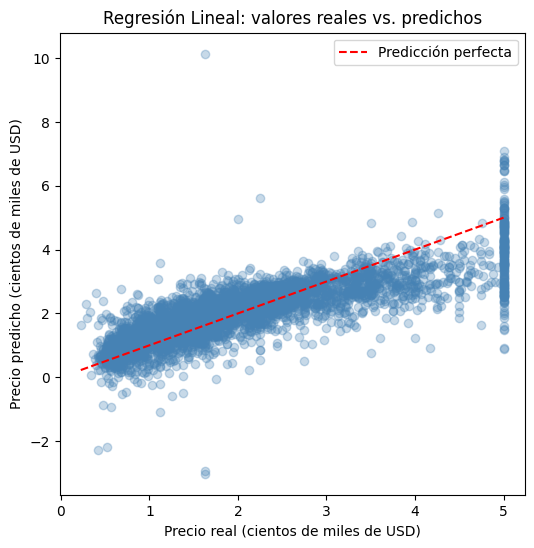

In [ ]:
plt.figure(figsize=(6, 6))  # Creo una figura cuadrada para que la comparación se vea equilibrada.
plt.scatter(y_test, predicciones_lineal, alpha=0.3, color='steelblue')  # Grafico cada predicción contra su valor real; si el modelo fuera perfecto, todos los puntos caerían sobre la línea punteada.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predicción perfecta')  # Dibujo la línea ideal como referencia visual.
plt.xlabel('Precio real (cientos de miles de USD)')  # Etiqueto el eje X: los valores verdaderos que el modelo no vio.
plt.ylabel('Precio predicho (cientos de miles de USD)')  # Etiqueto el eje Y: lo que el modelo estimó.
plt.title('Regresión Lineal: valores reales vs. predichos')  # Título que describe exactamente qué estamos comparando.
plt.legend()  # Añado la leyenda para identificar la línea de predicción perfecta.
plt.show()  # Muestro la gráfica.

**Qué observo:** los puntos siguen la diagonal en la zona de precios bajos y medios (el grueso de los datos), pero se dispersan visiblemente para precios altos y el modelo **casi no predice por encima de ~4.9**. Dos efectos combinados: el techo propio de una línea recta ante relaciones curvas, y el truncamiento del censo en 5.0, que "aplasta" las predicciones de las viviendas más caras.

### 12.2 Árbol de Decisión: valores reales vs. predichos

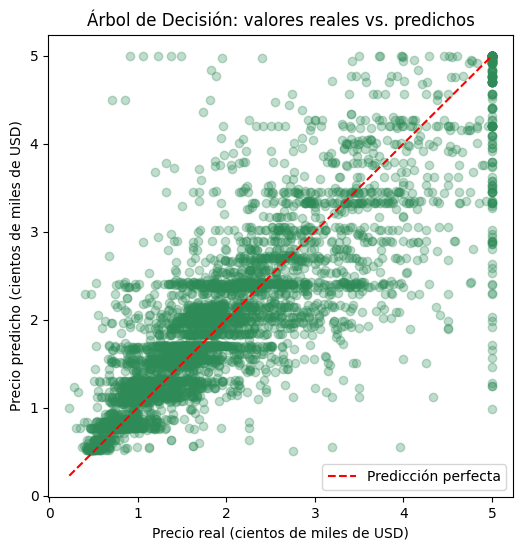

In [ ]:
plt.figure(figsize=(6, 6))  # Repito la misma estructura de gráfica para comparar visualmente con el modelo lineal.
plt.scatter(y_test, predicciones_arbol, alpha=0.3, color='seagreen')  # Grafico las predicciones del árbol contra los valores reales del mismo conjunto de prueba.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predicción perfecta')  # Misma línea ideal, para comparar justo con la gráfica anterior.
plt.xlabel('Precio real (cientos de miles de USD)')  # Etiqueto el eje X igual que antes, manteniendo la comparación consistente.
plt.ylabel('Precio predicho (cientos de miles de USD)')  # Etiqueto el eje Y con las predicciones del árbol.
plt.title('Árbol de Decisión: valores reales vs. predichos')  # Título que indica que este gráfico corresponde al segundo modelo.
plt.legend()  # Añado la leyenda de la línea de referencia.
plt.show()  # Muestro la gráfica.

**Qué observo:** la nube de puntos está algo más pegada a la diagonal que en la regresión lineal, sobre todo en la zona media. También se nota una **textura de "banda" horizontal**: el árbol predice valores discretos (promedios de sus hojas), no cualquier número. Se sigue viendo dispersión en los precios altos, donde el truncamiento del censo limita a ambos modelos.

### 12.3 Comparación visual de métricas entre modelos

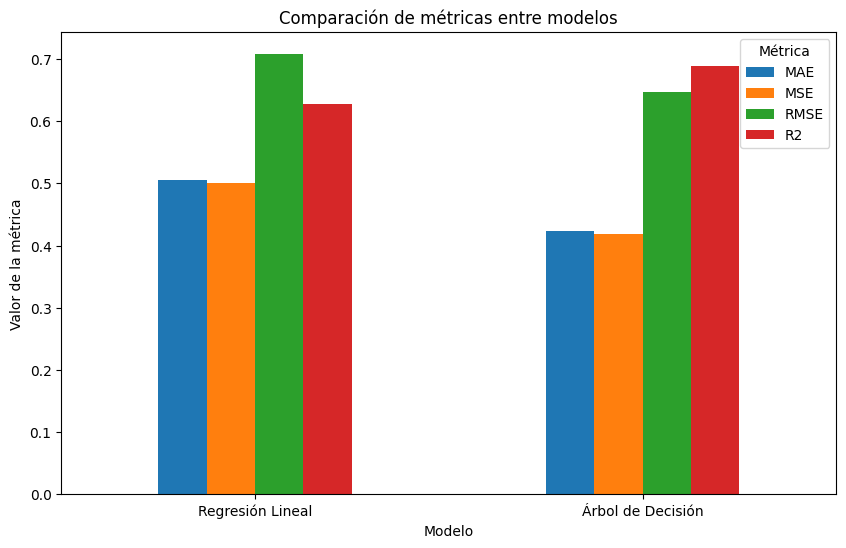

In [ ]:
metricas_graficar = resultados.set_index('Modelo')[['MAE', 'MSE', 'RMSE', 'R2']]  # Preparo las métricas de ambos modelos para graficarlas agrupadas.
metricas_graficar.plot(kind='bar', figsize=(10, 6))  # Dibujo una gráfica de barras comparando ambos modelos en cada métrica de un vistazo.
plt.ylabel('Valor de la métrica')  # Etiqueto el eje Y, ya que cada barra representa el puntaje de una métrica.
plt.title('Comparación de métricas entre modelos')  # Título que indica que estamos comparando el desempeño general.
plt.xticks(rotation=0)  # Dejo los nombres de los modelos horizontales para que se lean fácilmente.
plt.legend(title='Métrica')  # Añado leyenda para saber qué color corresponde a cada métrica.
plt.show()  # Muestro la gráfica comparativa.

**Qué observo:** en las tres métricas de error (MAE, MSE, RMSE) las barras del árbol son menores que las de la regresión lineal, y en R² es mayor. Visualmente queda claro que **el árbol domina en las cuatro métricas**, aunque por márgenes moderados, no abismales: ninguno de los dos modelos resuelve el problema por completo.

## 13. Análisis de resultados

* **¿Cuál modelo obtuvo mejor desempeño?** El Árbol de Decisión en las cuatro métricas: MAE 0.4239 vs 0.5047, RMSE 0.6473 vs 0.7076 y R² 0.6890 vs 0.6283.
* **¿Por qué pudo haber obtenido mejores resultados?** Principalmente por la **ubicación geográfica**: `Latitude` y `Longitude` se relacionan con el precio por regiones (la costa californiana es cara), un patrón no lineal que el árbol divide naturalmente y la recta no puede seguir. También captura umbrales (p. ej., el ingreso solo "empuja" el precio hasta cierto punto).
* **¿La relación parece lineal?** Parcialmente. Con el ingreso mediano (`MedInc`) sí lo es en buena medida (correlación 0.69), pero el R² del modelo lineal (0.63) muestra que una recta se queda corta: deja sin explicar más de un tercio de la variación.
* **¿El árbol capturó relaciones que la regresión no pudo?** Sí, lo confirman los ~6 puntos de R² adicionales en prueba: regiones geográficas y combinaciones de características.
* **¿Existe evidencia de sobreajuste?** Sí, en el árbol: R² de 0.8332 en entrenamiento vs 0.6890 en prueba. El `max_depth=10` controló parte del problema (sin límite la brecha sería mucho mayor), pero aún memoriza algo de ruido. El modelo lineal apenas sobreajusta (0.6465 → 0.6283), porque su simpleza es también su protección.
* **¿Qué variables parecen influir más?** `MedInc` es la dominante (mayor correlación y mayor coeficiente lineal). Le siguen la ubicación (`Latitude`, `Longitude`) y, dentro del árbol, las divisiones geográficas. `Population` y `AveOccup` aportan muy poco.
* **Ventajas de la regresión lineal:** simple, estable, casi sin sobreajuste, interpretable vía coeficientes, muy rápida.
* **Desventajas de la regresión lineal:** no captura relaciones no lineales ni por regiones; tiene techo de precisión en este problema.
* **Ventajas del árbol:** captura no linealidades y umbrales; requiere poco preprocesamiento; mejor desempeño aquí.
* **Desventajas del árbol:** inestable (cambia mucho si cambian los datos), propenso al overfitting, difícil de interpretar cuando crece, y predice valores "en escalones".
* **¿Qué mejorar en una segunda versión?** (1) Regularizar el árbol probando `max_depth` y `min_samples_leaf` con validación cruzada, o pasar a un **Random Forest** que promedia muchos árboles y reduce el sobreajuste; (2) crear variables nuevas como `bedroom_ratio = AveBedrms / AveRooms` o distancia a la costa; (3) tratar explícitamente el truncamiento de precios en 5.0 (modelos tobit o eliminando el tope con criterio); (4) probar Gradient Boosting (XGBoost/LightGBM), que suele ganar en tablas de precios.

## 14. Conclusiones

Trabajar este dataset me dejó aprendizajes concretos, no genéricos:

1. **El ingreso del vecindario es el motor del precio**, pero no lo explica todo: la ubicación geográfica (que opera por regiones, no linealmente) aporta una mejora real y medible, exactamente los ~6 puntos de R² que le ganó el árbol a la recta.
2. **El Árbol de Decisión fue el mejor modelo** de esta comparación (MAE ≈ USD $42,390 frente a ≈ USD $50,470 de la regresión lineal, en el conjunto de prueba), porque el problema tiene patrones no lineales que la recta no puede seguir.
3. **Las predicciones son útiles como estimación inicial**, con un error promedio del orden de USD $40,000–50,000 sobre viviendas de ~USD $180,000 en promedio: orientan, pero no sustituyen una tasación profesional.
4. **El sobreajuste es un enemigo real**: sin límite de profundidad, el árbol habría memorizado el entrenamiento y reportado cifras engañosas. Medir R² en ambos conjuntos me permitió detectarlo y reportarlo con honestidad en lugar de esconderlo.
5. **El truncamiento del censo en USD $500,000** limita el techo de ambos modelos: ninguno predice bien las viviendas más caras, y eso es una limitación del dato, no solo de los algoritmos.
6. **El modelo más simple no siempre gana, pero tampoco se descarta gratis**: la regresión lineal sigue siendo valiosa por su estabilidad e interpretabilidad, y como base de comparación obligatoria.

## 15. Posibles mejoras

Para una segunda entrega consideraría:

* **Validación cruzada** y búsqueda de hiperparámetros (`GridSearchCV`) para la profundidad y `min_samples_leaf` del árbol, en lugar de fijarlos a criterio.
* **Ensambles:** Random Forest y Gradient Boosting (XGBoost/LightGBM), que atacan directamente la inestabilidad y el sobreajuste del árbol individual.
* **Ingeniería de características:** ratios como habitaciones por dormitorio, y transformar latitud/longitud en una variable de "distancia a la costa".
* **Tratamiento del truncamiento** del precio en 5.0 (por ejemplo, entrenar solo con precios < 5.0 y evaluar por separado el segmento alto).
* **Análisis de residuos** por rangos de precio para detectar dónde falla sistemáticamente cada modelo.
* **Anexar al README** los resultados y una guía de ejecución en Colab para que cualquier persona pueda reproducir el proyecto.

## 16. Preparación para GitHub

### Estructura propuesta del repositorio

```
prediccion-precios-vivienda/
│
├── README.md                  # Descripción, objetivos, cómo ejecutar, resultados
├── modelo_prediccion.ipynb    # Este notebook, listo para Colab
├── dataset/
│   └── dataset.csv            # Copia del dataset (o nota de cómo descargarlo)
├── resultados/
│   └── metricas.csv           # Tabla comparativa exportada (opcional)
└── graficas/
    └── comparacion_modelos.png  # Gráficas exportadas (opcional)
```

### Qué debe contener el `README.md`

1. **Título y descripción** del proyecto (qué se predice y con qué dataset).
2. **Objetivo académico** y modelos comparados.
3. **Instrucciones de ejecución** en Google Colab (abrir notebook → Runtime → Run all, o el enlace "Open in Colab").
4. **Resumen de resultados:** la tabla de métricas y la conclusión de cuál modelo ganó.
5. **Estructura del repositorio** y tecnologías usadas (Python, scikit-learn, pandas...).
6. **Autor, asignatura y fecha.**

### Comandos Git para publicar el proyecto

```bash
# 1. Crear la carpeta del proyecto y entrar a ella
mkdir prediccion-precios-vivienda
cd prediccion-precios-vivienda

# 2. Inicializar el repositorio local
git init

# 3. Agregar todos los archivos del proyecto al área de preparación
git add .

# 4. Crear el primer commit con un mensaje descriptivo
git commit -m "Primer commit: proyecto de predicción de precios de vivienda con regresión lineal y árbol de decisión"

# 5. Crear el repositorio en GitHub (desde la página web) y conectarlo.
#    IMPORTANTE: reemplaza la URL por la de TU propio repositorio:
git remote add origin https://github.com/TU_USUARIO/prediccion-precios-vivienda.git

# 6. Subir los archivos a GitHub
git push -u origin main
```

> ⚠️ **Nota:** antes del `push`, asegúrate de crear el repositorio vacío en github.com y de copiar **tu propia URL** en el paso 5. Si tu rama principal se llama `master` en lugar de `main`, ajusta el último comando.